In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [2]:

# Read an Excel file (XLSX)
df = pd.read_excel("M2.xlsx")

# Display the first few rows
df.head()

,Date,M2 YoY Growth Rate,M2 MoM Growth Rate,China Money Supply M2 (Trillion CNY),CPI YoY,PPI YoY
0,2025-04-30,0.079616,-0.002704,325.173932,-0.001,-0.027
1,2025-03-31,0.069753,0.017279,326.055457,-0.001,-0.025
2,2025-02-28,0.069970,0.006256,320.517324,-0.001,-0.022
3,2025-01-31,0.070222,0.015923,318.524718,-0.007,-0.023
4,2024-12-31,0.072744,0.005044,313.532230,0.005,-0.023


In [3]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%b %Y')

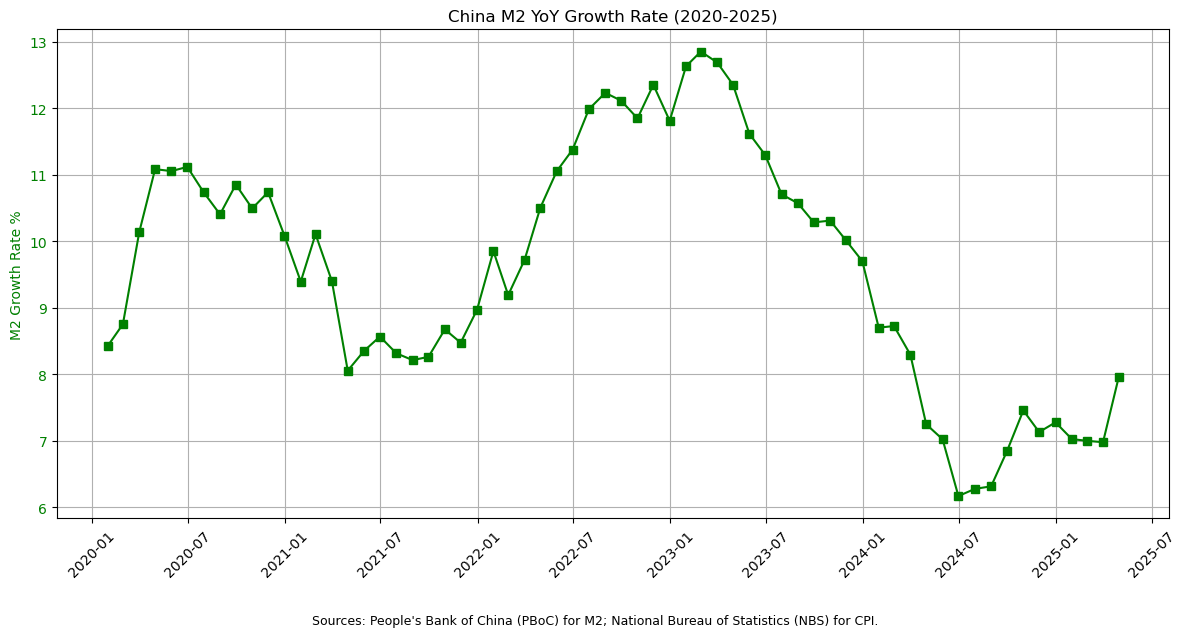

In [27]:
# Create the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left Y-axis: M2
line1, = ax1.plot(df['Date'], df['M2 YoY Growth Rate']*100, color='green', marker='s', label='M2 YoY Growth Rate')
ax1.set_ylabel('M2 Growth Rate %', color='green')
ax1.tick_params(axis='y', labelcolor='green')

# Format x-axis
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

# Title and layout
plt.title("China M2 YoY Growth Rate (2020-2025)")
fig.tight_layout()
plt.grid(True)

# Data source text
plt.figtext(
    0.5, -0.05,
    "Sources: People's Bank of China (PBoC) for M2; National Bureau of Statistics (NBS) for CPI.",
    wrap=True, horizontalalignment='center', fontsize=9
)
#plt.figtext(
#    0.5, -0.10,
#   "Figure 1",
#   wrap=True, horizontalalignment='center', fontsize=10, fontweight='bold'
#)

plt.show()

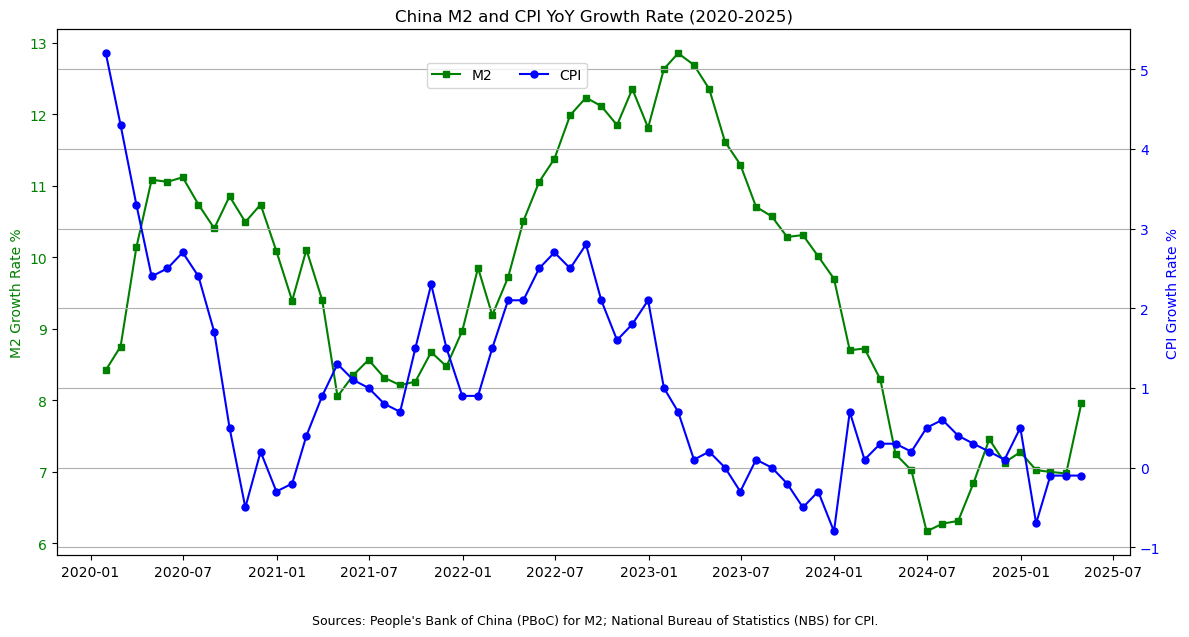

In [28]:
# Create the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left Y-axis: M2
line1, = ax1.plot(df['Date'], df['M2 YoY Growth Rate']*100, color='green', marker='s',markersize=5,  label='M2')
ax1.set_ylabel('M2 Growth Rate %', color='green')
ax1.tick_params(axis='y', labelcolor='green')

# Right Y-axis: CPI
ax2 = ax1.twinx()
line2, = ax2.plot(df['Date'], df['CPI YoY']*100, color='blue', marker='o', markersize=5, label='CPI')
ax2.set_ylabel('CPI Growth Rate %', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Format x-axis
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

# Title and layout
plt.title("China M2 and CPI YoY Growth Rate (2020-2025)")
fig.tight_layout()
plt.grid(True)

# Place combined legend under title
plt.legend(handles=[line1, line2], loc='upper right', bbox_to_anchor=(0.5, 0.95), ncol=2)

# Data source text
plt.figtext(
    0.5, -0.05,
    "Sources: People's Bank of China (PBoC) for M2; National Bureau of Statistics (NBS) for CPI.",
    wrap=True, horizontalalignment='center', fontsize=9
)
#plt.figtext(
#    0.5, -0.10,
#   "Figure 1",
#   wrap=True, horizontalalignment='center', fontsize=10, fontweight='bold'
#)

plt.show()

In [6]:
cpi_df= pd.read_excel("CPI_2016_2025.xlsx")
# Display the first few rows
cpi_df.head()


,Date,M2 YoY Growth Rate,M2 MoM Growth Rate,China Money Supply M2 (100 million CNY),China Money Supply M2 (Trillion CNY),居民消费价格指数(上年同月=100),CPI YoY,工业生产者出厂价格指数(上年同月=100),PPI YoY
0,2025-04-30,0.079616,-0.002704,3251739.32,325.173932,99.9,-0.001,97.3,-0.027
1,2025-03-31,0.069753,0.017279,3260554.57,326.055457,99.9,-0.001,97.5,-0.025
2,2025-02-28,0.069970,0.006256,3205173.24,320.517324,99.9,-0.001,97.8,-0.022
3,2025-01-31,0.070222,0.015923,3185247.18,318.524718,99.3,-0.007,97.7,-0.023
4,2024-12-31,0.072744,0.005044,3135322.30,313.532230,100.5,0.005,97.7,-0.023


In [7]:
# Convert 'Date' to datetime
cpi_df['Date'] = pd.to_datetime(cpi_df['Date'], format='%b %Y')

In [8]:
cpi_avg_2016_2020 = cpi_df[(cpi_df['Date'] >= '2016-01-01') & (cpi_df['Date'] <= '2020-12-31')]['CPI YoY'].mean() * 100
cpi_avg_2021_2025 = cpi_df[(cpi_df['Date'] >= '2021-01-01') & (cpi_df['Date'] <= '2025-12-31')]['CPI YoY'].mean() * 100

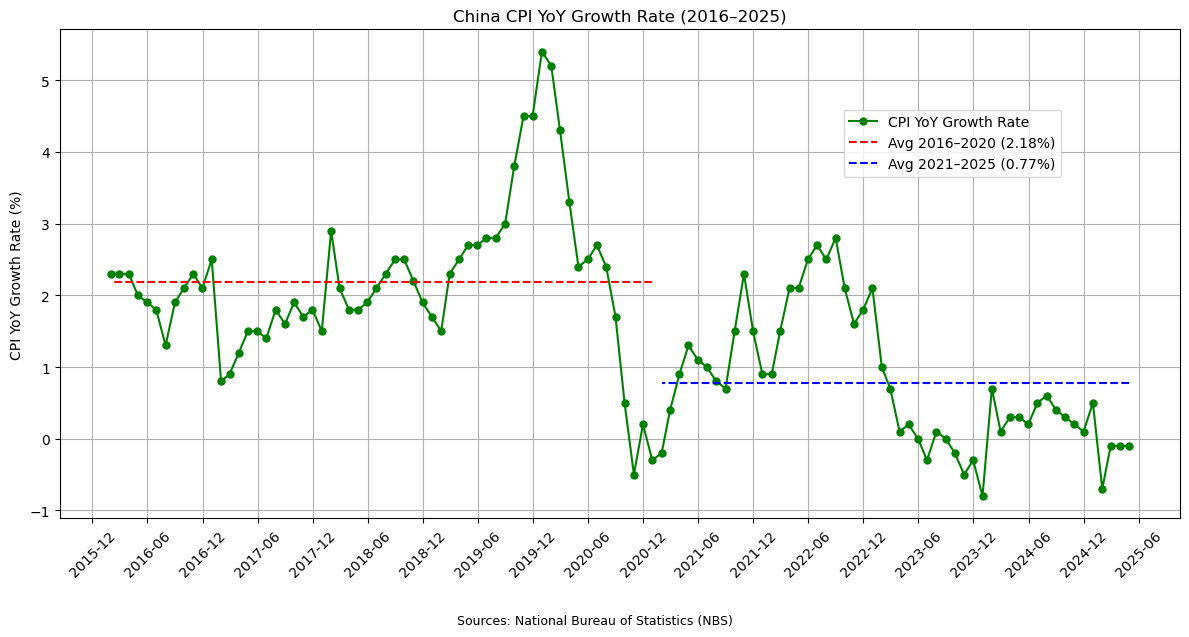

In [41]:
# Plot CPI YoY Growth Rate
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cpi_df['Date'], cpi_df['CPI YoY'] * 100, color='green', marker='o', markersize=5, label='CPI YoY Growth Rate')

# Draw horizontal average lines only over their respective time periods
period_1 = cpi_df[(cpi_df['Date'] >= '2016-01-01') & (cpi_df['Date'] <= '2020-12-31')]
period_2 = cpi_df[(cpi_df['Date'] >= '2021-01-01') & (cpi_df['Date'] <= '2025-12-31')]

ax.plot(period_1['Date'], [cpi_avg_2016_2020] * len(period_1), color='red', linestyle='--', linewidth=1.5, label='Avg 2016–2020 (2.18%)')
ax.plot(period_2['Date'], [cpi_avg_2021_2025] * len(period_2), color='blue', linestyle='--', linewidth=1.5, label='Avg 2021–2025 (0.77%)')

# Formatting
ax.set_ylabel('CPI YoY Growth Rate (%)')
ax.set_title('China CPI YoY Growth Rate (2016–2025)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(loc='upper right',bbox_to_anchor=(0.9, 0.85))

# Data source
plt.figtext(
    0.5, -0.05,
    "Sources: National Bureau of Statistics (NBS)",
    wrap=True, horizontalalignment='center', fontsize=9
)

plt.tight_layout()
plt.show()

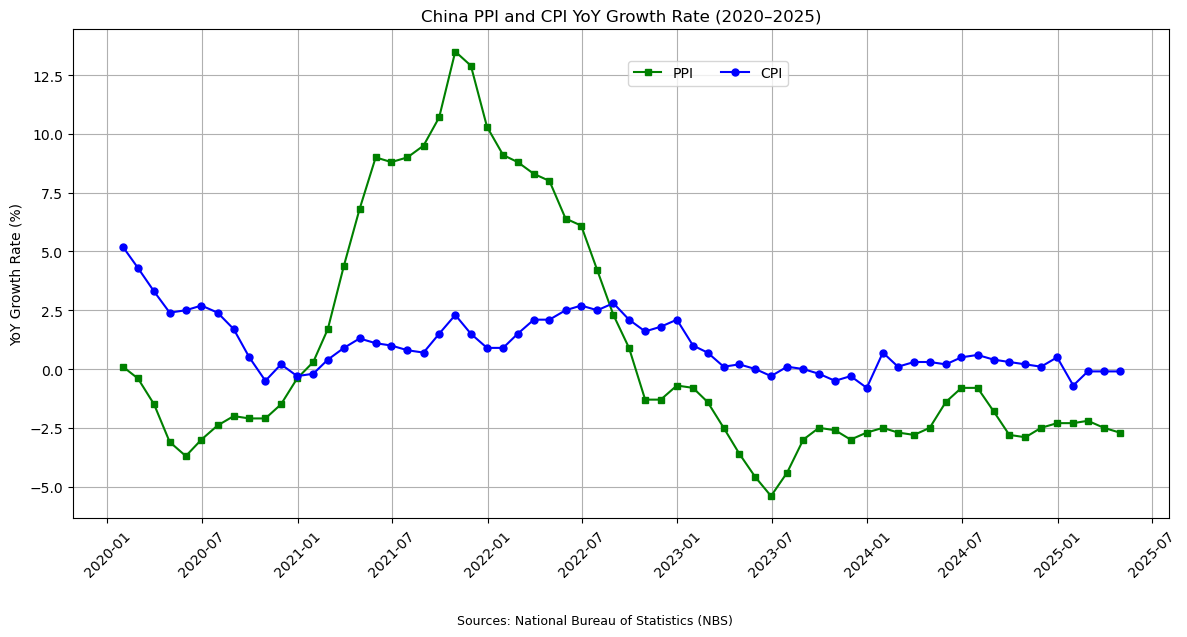

In [24]:
# Create the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot PPI and CPI on the same Y-axis
line1, = ax1.plot(df['Date'], df['PPI YoY']*100, color='green', marker='s', markersize=5, label='PPI')
line2, = ax1.plot(df['Date'], df['CPI YoY']*100, color='blue', marker='o', markersize=5,  label='CPI')

# Y-axis label
ax1.set_ylabel('YoY Growth Rate (%)')
ax1.tick_params(axis='y')

# Format x-axis
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

# Title and layout
plt.title("China PPI and CPI YoY Growth Rate (2020–2025)")
fig.tight_layout()
plt.grid(True)

# Combined legend
plt.legend(loc='upper left', bbox_to_anchor=(0.5, 0.95), ncol=2)

# Data source text
plt.figtext(
    0.5, -0.05,
    "Sources: National Bureau of Statistics (NBS)",
    wrap=True, horizontalalignment='center', fontsize=9
)

plt.show()

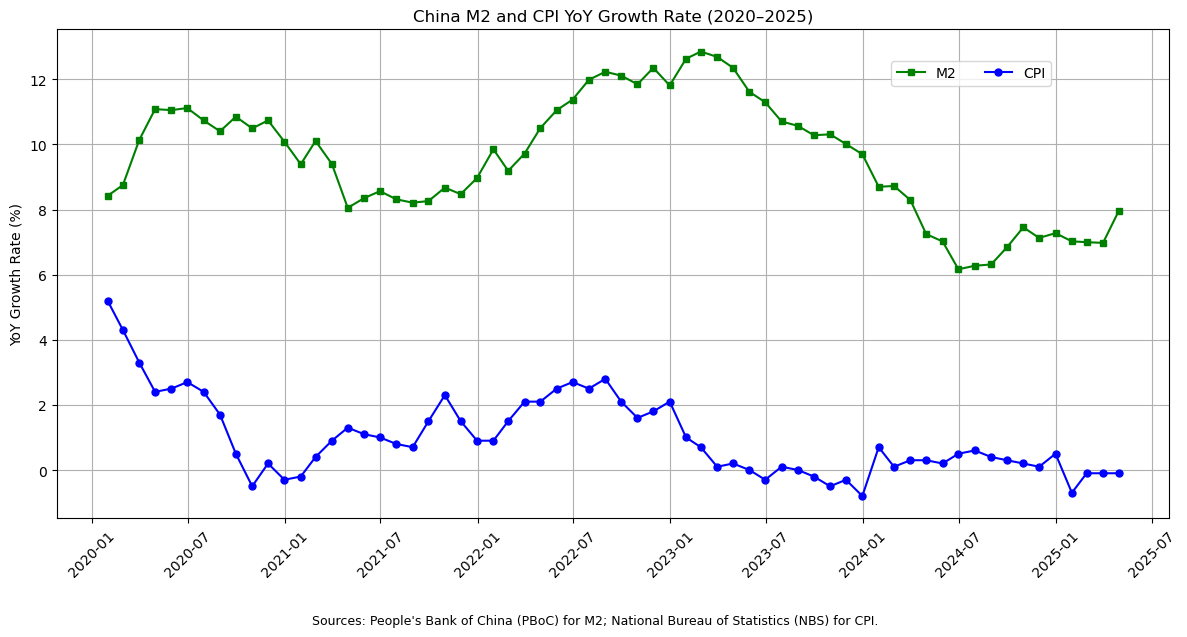

In [36]:
# Create the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot M2 and CPI on the same Y-axis
line1, = ax1.plot(df['Date'], df['M2 YoY Growth Rate']*100, color='green', marker='s', markersize=5, label='M2')
line2, = ax1.plot(df['Date'], df['CPI YoY']*100, color='blue', marker='o', markersize=5, label='CPI')

# Y-axis
ax1.set_ylabel('YoY Growth Rate (%)')
ax1.tick_params(axis='y')

# X-axis
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

# Title and layout
plt.title("China M2 and CPI YoY Growth Rate (2020–2025)")
fig.tight_layout()
plt.grid(True)

# Legend
plt.legend(loc='upper right', bbox_to_anchor=(0.9, 0.95), ncol=2)

# Data source text
plt.figtext(
    0.5, -0.05,
    "Sources: People's Bank of China (PBoC) for M2; National Bureau of Statistics (NBS) for CPI.",
    wrap=True, horizontalalignment='center', fontsize=9
)

plt.show()

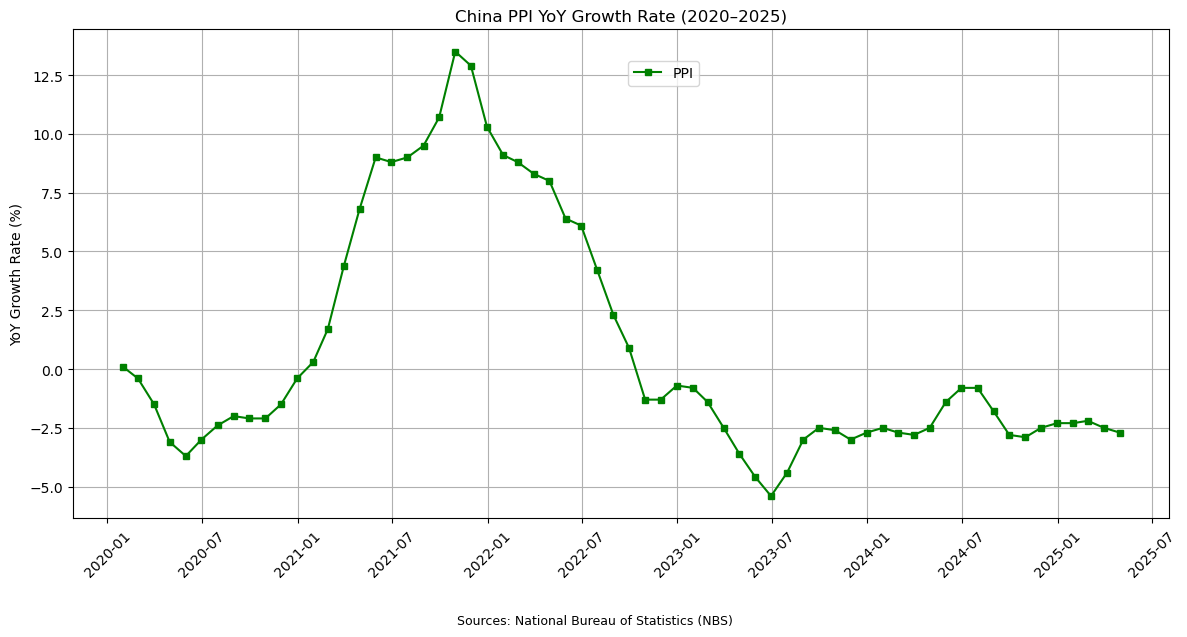

In [ ]:
# Create the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot PPI 
line1, = ax1.plot(df['Date'], df['PPI YoY']*100, color='green', marker='s', markersize=5, label='PPI')
#line2, = ax1.plot(df['Date'], df['CPI YoY']*100, color='blue', marker='o', markersize=5,  label='CPI')

# Y-axis label
ax1.set_ylabel('YoY Growth Rate (%)')
ax1.tick_params(axis='y')

# Format x-axis
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

# Title and layout
plt.title("China PPI YoY Growth Rate (2020–2025)")
fig.tight_layout()
plt.grid(True)

# Combined legend
plt.legend(loc='upper left', bbox_to_anchor=(0.5, 0.95), ncol=2)

# Data source text
plt.figtext(
    0.5, -0.05,
    "Sources: National Bureau of Statistics (NBS)",
    wrap=True, horizontalalignment='center', fontsize=9
)

plt.show()